## Customer Segmentation Analysis

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("sales data.csv")
df.head(3)

,Order ID,Date,Customer ID,Product,Quantity,Revenue
0,1001,05-01-2023,C001,Laptop,1.0,1200.0
1,1002,05-01-2023,C002,Mouse,NaN,50.0
2,1003,06-01-2023,C001,Keyboard,1.0,75.0


In [4]:
df.isnull().sum()

Order ID       0
Date           0
Customer ID    0
Product        0
Quantity       1
Revenue        1
dtype: int64

In [5]:
df.describe()

,Order ID,Quantity,Revenue
count,10.00000,9.000000,9.000000
mean,1005.50000,1.111111,238.888889
std,3.02765,0.333333,374.422704
min,1001.00000,1.000000,25.000000
25%,1003.25000,1.000000,50.000000
50%,1005.50000,1.000000,80.000000
75%,1007.75000,1.000000,280.000000
max,1010.00000,2.000000,1200.000000


In [8]:
df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)
df['Revenue'].fillna(df['Revenue'].mean(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_5816\3891990465.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_5816\3891990465.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [9]:
df.isnull().sum()

Order ID       0
Date           0
Customer ID    0
Product        0
Quantity       0
Revenue        0
dtype: int64

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
customer_data = df.groupby('Customer ID').agg({
    'Revenue':'sum',
    'Quantity':'sum',
    'Order ID ':'count'
}).reset_index()

In [12]:
customer_data.columns = ['CustomerID','TotalRevenue','TotalQuantity','TotalOrders']

In [13]:
customer_data.head()

,CustomerID,TotalRevenue,TotalQuantity,TotalOrders
0,C001,1375.000000,4.000000,3
1,C002,90.000000,2.111111,2
2,C003,325.000000,2.000000,2
3,C004,518.888889,2.000000,2
4,C005,80.000000,1.000000,1


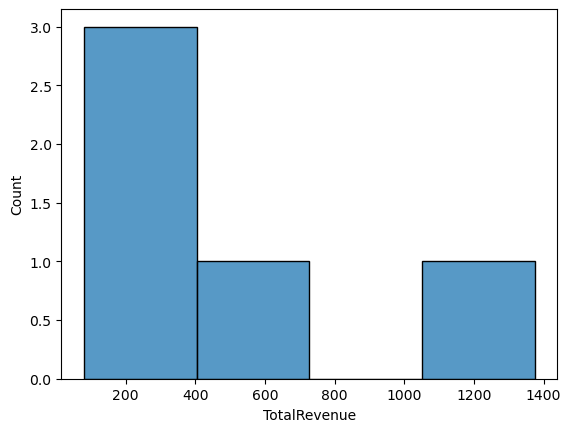

In [14]:
sns.histplot(customer_data['TotalRevenue'])
plt.show()

C:\Users\HP\Documents\jup\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\Documents\jup\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\Documents\jup\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\Documents\jup\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

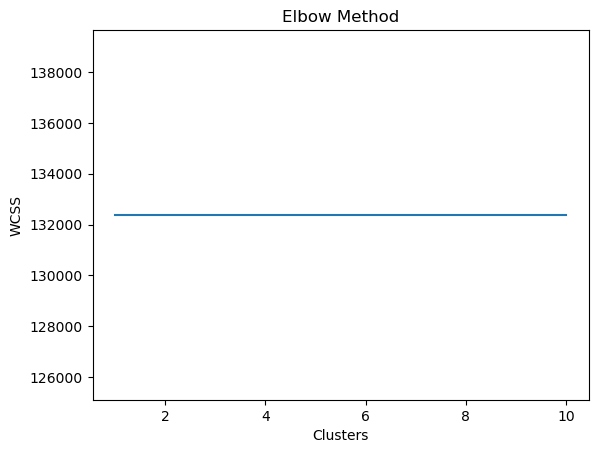

In [17]:
from sklearn.cluster import KMeans

X = customer_data[['TotalRevenue','TotalOrders']]

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)

customer_data['Cluster'] = kmeans.fit_predict(X)

C:\Users\HP\Documents\jup\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


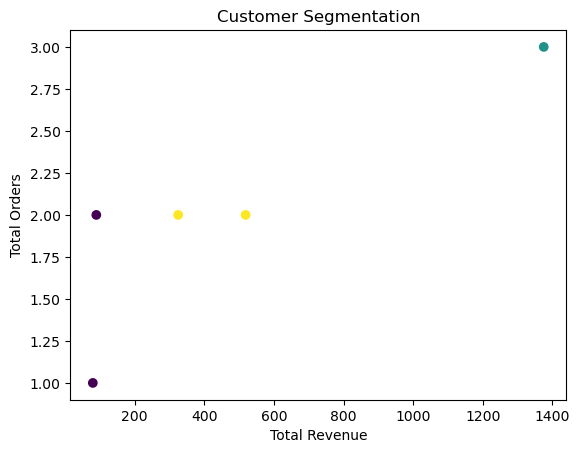

In [19]:
plt.scatter(customer_data['TotalRevenue'],
            customer_data['TotalOrders'],
            c=customer_data['Cluster'])

plt.xlabel('Total Revenue')
plt.ylabel('Total Orders')

plt.title('Customer Segmentation')

plt.show()

- Premium customers generate maximum revenue.
- Low-value customers need promotional offers.
- Regular customers can be converted into premium customers.